<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/NOTEBOOK_PROFESSOR_RODRIGO_PERCEPTRON_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


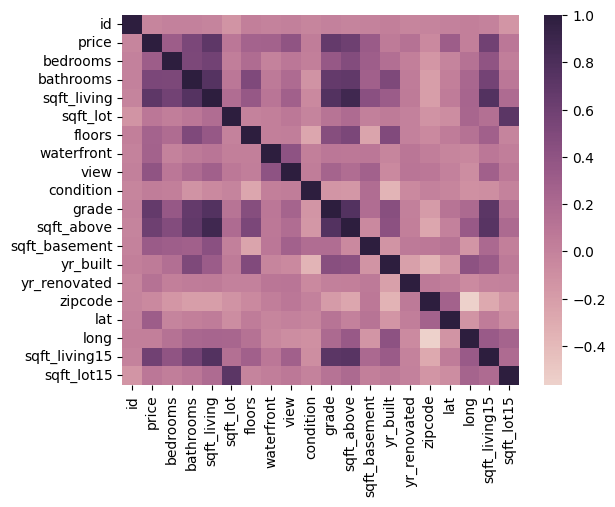

In [ ]:
from sklearn.model_selection import train_test_split # Biblioteca para separação de amostras de treino e teste, curva de aprendizagem do treinamento
from sklearn.neural_network import MLPRegressor # Biblioteca para utilização do Regressor MLP
from sklearn.preprocessing import StandardScaler # Biblioteca para normalização dos dados
from sklearn.pipeline import Pipeline # Biblioteca para organização de ações em sequência
from sklearn import metrics # Biblioteca para avaliação das métricas do modelo
import matplotlib.pyplot as plt # Biblioteca para plotagem de gráficos
import numpy as np # Biblioteca para manipulação de arrays Numpy
import pandas as pd # Biblioteca para manipulação de dados, importação e manipulação inicial do dataset
from google.colab import drive # Biblioteca para interação do colab com o Drive
drive.mount('/content/drive') # Montar o Google Drive na mesma conta do Google Colab
import seaborn as sns # Biblioteca para visualização de dados Python baseado em matplotlib.

# Caminho do dataset no Google Drive será carregado em df
df = pd.read_csv("/content/drive/MyDrive/RNA_Datasets/kc_house_data (9).csv") # Professor Rodrigo, fiz o upload do dataset, botão direito em copiar caminho e depois colei.

## RNA_Datasets É A PASTA QUE VOCÊ DEVE CRIAR NO SEU GOOGLE DRIVE e o kc_house_data.csv DEVE ESTAR DENTRO DA PASTA

# Gera um gráfico matricial para apresentar a correção entre as variáveis de entrada do dataset
ax = sns.heatmap(df.corr(numeric_only=True), annot=False, cmap=sns.cubehelix_palette(as_cmap=True))
ax=ax



In [ ]:
# Exclusão das variáveis não relevantes do Dataset
df = df.drop(['id','date', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long'], axis=1)

# Exibe as 5 primeiras amostras
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1800,7503


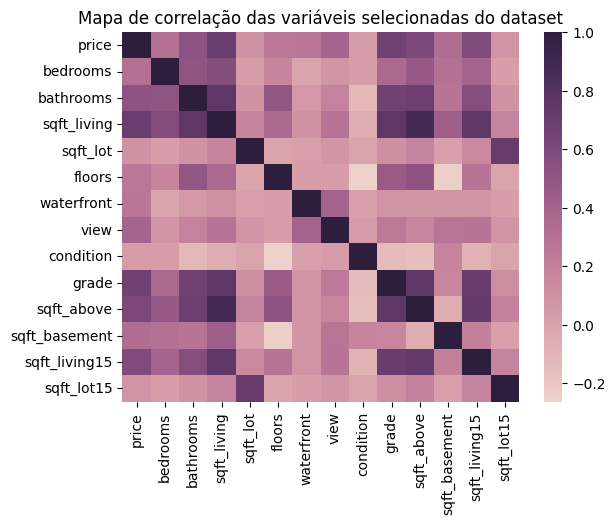

In [ ]:
bx = sns.heatmap(df.corr(numeric_only=True), annot=False, cmap=sns.cubehelix_palette(as_cmap=True))
bx.set_title('Mapa de correlação das variáveis selecionadas do dataset')
bx=bx

In [ ]:
x = df.drop('price', axis=1) # Exclusão da variável price das entradas
y = df['price'] # Inclusão da variável price no vetor das saídas desejadas
maxY = y.max()
y = y/maxY # Normalização dos dados de saída
print(maxY)


7700000.0


In [ ]:
scaler = StandardScaler().fit(x) # Criação o modelo para o ajuste
x = scaler.transform(x) # Aplica a padronização do dataset de treinamento baseado nos dados de treinamento
trainX, testX, trainY, testY = train_test_split(x, y, test_size=0.30)

In [ ]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(50), activation='logistic', solver='adam',
          max_iter=5000, tol=0.0000001, momentum=0.8, early_stopping=True, epsilon=1e-08,
          n_iter_no_change=10, random_state = 12)

# Execução do treinamento da RNA, no primeiro parâmetro são os dados de entrada e no segundo parâmetro são os dados da saída
mlp_reg.fit(trainX, trainY)

MLPRegressor(activation='logistic', early_stopping=True, hidden_layer_sizes=50,
             max_iter=5000, momentum=0.8, random_state=12, tol=1e-07)

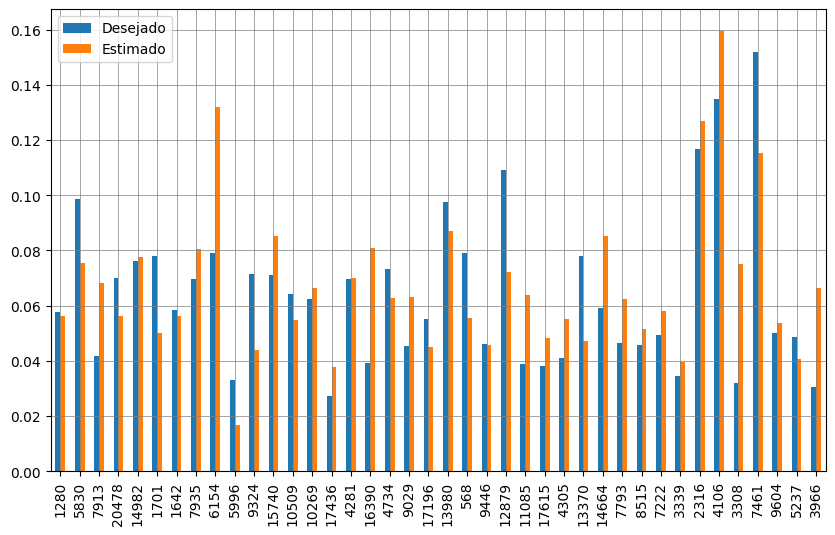

In [ ]:
# predict() Executa a predição das saídas baseado no modelo treinado no passo anterior
# com dados não apresentados no treinamento da RNA
y_pred = mlp_reg.predict(testX)
df_temp = pd.DataFrame({'Desejado': testY, 'Estimado': y_pred})
df_temp = df_temp.head(40)
df_temp.plot(kind='bar', figsize=(10,6))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.show() # Apresenta o gráfico comparando o desejado e o estimado pelo modelo neural

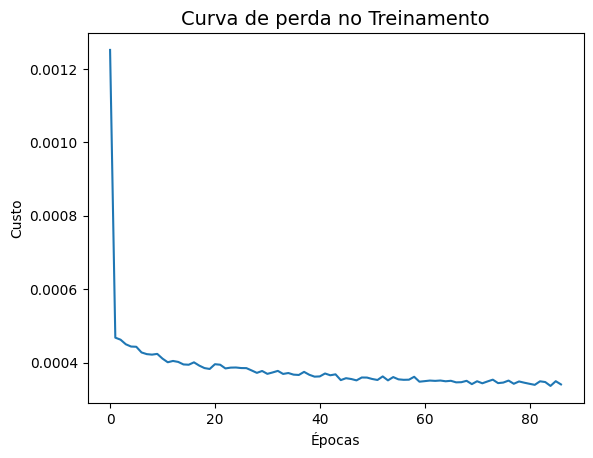

In [ ]:
plt.plot(mlp_reg.loss_curve_)
plt.title("Curva de perda no Treinamento", fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.show() # Apresenta a curva de perda do treinamento da RNA

In [ ]:
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(testY, y_pred)) # Variação de 0 ao infinito, Quanto menor, melhor
print('Mean Squared Error (MSE):', metrics.mean_squared_error(testY, y_pred)) # Variação de 0 ao infinito, Quanto menor, melhor
rmse = (metrics.mean_squared_error(testY, y_pred)) ** 0.5
print('Root Mean Squared Error (RMSE):', rmse)
print('Mean Absolute Percentage Error (MAPE):', metrics.mean_absolute_percentage_error(testY, y_pred)) # Apresentação em porcentagem


Mean Absolute Error (MAE): 0.01786989293390891
Mean Squared Error (MSE): 0.000737430888461793
Root Mean Squared Error (RMSE): 0.027155678751631177
Mean Absolute Percentage Error (MAPE): 0.27172475971628157
